In [23]:
#  %pip install tensorly

Создадим тензор $\mathcal{A}$ из примера:

In [24]:
import tensorly as tl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
A = tl.tensor(np.array(np.arange(1, 9).reshape(2, 2, 2))).transpose(1, 2, 0)
print(A[:, :, 0])
print(A[:, :, 1])

[[1 2]
 [3 4]]
[[5 6]
 [7 8]]


Его развёртки:

In [26]:
print(tl.unfold(A, 0))
print(tl.unfold(A, 1))
print(tl.unfold(A, 2))

[[1 5 2 6]
 [3 7 4 8]]
[[1 5 3 7]
 [2 6 4 8]]
[[1 2 3 4]
 [5 6 7 8]]


Норма по Фробениусу:

In [27]:
print(tl.norm(A, 2))

14.2828568570857


Найдём приближённое CP ранга 1:

In [28]:
weights, factors = tl.decomposition.parafac(A, 1)
print("Полученные факторы:")
print(factors[0])
print(factors[1])
print(factors[2])
A_approx = np.zeros((2, 2, 2))
for i in range(2):
    for j in range(2):
        for k in range(2):
            A_approx[i, j, k] = factors[0][i] * factors[1][j] * factors[2][k]
print("Приближение ранга 1:")
print(A_approx)
print("Ошибка приближения:", tl.norm(A_approx - A)/tl.norm(A) * 100, "%")

Полученные факторы:
[[ 8.05549097]
 [11.72480302]]
[[0.6405734 ]
 [0.76789775]]
[[0.37594627]
 [0.9266415 ]]
Приближение ранга 1:
[[[1.93993283 4.78159361]
  [2.32552594 5.73201287]]

 [[2.82358088 6.95963081]
  [3.38481337 8.34297029]]]
Ошибка приближения: 8.960140221596793 %


C:\Users\vorkm\AppData\Local\Temp\ipykernel_32156\1371516502.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A_approx[i, j, k] = factors[0][i] * factors[1][j] * factors[2][k]


Ранга 2:

In [29]:
r = 2
weights, factors = tl.decomposition.parafac(A, r)
print("Полученные факторы:", factors[0])
print(factors[1])
print(factors[2])
A_approx = np.zeros((2, 2, 2))
for i in range(2):
    for j in range(2):
        for k in range(2):
            for alpha in range(r):
                A_approx[i, j, k] += factors[0][i, alpha] * factors[1][j, alpha] * factors[2][k, alpha]
print(f"Приближение ранга {r}:")
print(A_approx)
print("Ошибка приближения:", tl.norm(A_approx - A)/tl.norm(A) * 100, "%")

Полученные факторы: [[ 9.03309667 -0.65645124]
 [11.48562411 -0.39770235]]
[[0.6699344  1.16019695]
 [0.75537973 0.91006058]]
[[0.60467955 3.52037183]
 [0.97315808 1.12836942]]
Приближение ранга 2:
[[[0.97810804 5.0297656 ]
  [2.02287469 5.96616486]]

 [[3.02843065 6.96743208]
  [3.97206486 8.03473255]]]
Ошибка приближения: 0.5811166770219353 %


Найдём левые сингулярные векторы развёрток, факторы $U, V, W$ и ядро $G$:

In [30]:
X_1 = tl.unfold(A, 0)
X_2 = tl.unfold(A, 1)
X_3 = tl.unfold(A, 2)
U, s1, _ = np.linalg.svd(X_1)
V, s2, _ = np.linalg.svd(X_2)
W, s3, _ = np.linalg.svd(X_3)
G = np.einsum("abc,ia,jb,kc->ijk", A, U.T, V.T, W.T)
print("U:", U)
print("V:", V)
print("W:", W)
print("G:", G)
A_restored = np.einsum("abc,ia,jb,kc->ijk", G, U, V, W)
print("Тензор, восстановленный из разложения:", A_restored)

U: [[-0.56672424 -0.82390754]
 [-0.82390754  0.56672424]]
V: [[-0.64142303 -0.7671874 ]
 [-0.7671874   0.64142303]]
W: [[-0.37616823 -0.92655138]
 [-0.92655138  0.37616823]]
G: [[[-1.42253953e+01  4.61793060e-03]
  [ 1.60125603e-02  5.43770692e-01]]

 [[ 8.28025332e-03  1.11585148e+00]
  [ 2.38589095e-01  2.00114739e-01]]]
Тензор, восстановленный из разложения: [[[1. 5.]
  [2. 6.]]

 [[3. 7.]
  [4. 8.]]]


Можно сделать то же самое с помощью библиотеки tensorly:

In [31]:
core, factors = tl.decomposition.tucker(A, rank=[2, 2, 2])
for i in range(3):
    print(f"Factor {i + 1}:", factors[i])
print("Core:", core)

Factor 1: [[ 0.56672424  0.82390754]
 [ 0.82390754 -0.56672424]]
Factor 2: [[ 0.64142303  0.7671874 ]
 [ 0.7671874  -0.64142303]]
Factor 3: [[ 0.37616823  0.92655138]
 [ 0.92655138 -0.37616823]]
Core: [[[ 1.42253953e+01 -4.61793060e-03]
  [-1.60125603e-02 -5.43770692e-01]]

 [[-8.28025332e-03 -1.11585148e+00]
  [-2.38589095e-01 -2.00114739e-01]]]


Реализуем простой алгоритм с Disjoint Components: посчитаем Tucker тензора, в каждой строчке факторов оставим только самое большое по модулю число и пересчитаем ядро по формуле $G=[[A; U^T, V^T, W^T]]$:

In [32]:
class DisjointTucker:
    def __init__(self, ranks=None, n_iter_max = 100, tol=1e-4, random_state=None):
        self.ranks = ranks
        self.n_iter_max = n_iter_max
        self.tol = tol
        self.random_state = random_state
        
        self.core = None
        self.factors = None
    
    def tucker_fit(self, X: tl.tensor):
        self.core, self.factors = tl.decomposition.tucker(X, rank=self.ranks, n_iter_max=self.n_iter_max, tol=self.tol, random_state=self.random_state)
        return self
    
    def tucker_fit_transform(self, X: tl.tensor):
        self.tucker_fit(X)
        return self.core, self.factors

    def make_disjoint(self, M: tl.tensor):
        M_new = np.zeros_like(M)
        idx = np.argmax(np.abs(M), axis=1)

        for i in range(M.shape[0]):
            M_new[i, idx[i]] = np.abs(M[i, idx[i]])

        return M_new

    def disjoint_transform(self, X: tl.tensor, idxs=None):
        if idxs == None:
            idxs = list(range(len(X.shape)))
        for i in idxs:
            self.factors[i] = self.make_disjoint(self.factors[i])
        return self

    def compute_core(self, X: tl.tensor):
        self.core = np.einsum("abc,ia,jb,kc->ijk", X, self.factors[0].T, self.factors[1].T, self.factors[2].T)
        return self

    def fit(self, X: tl.tensor):
        self.tucker_fit(X)
        self.disjoint_transform(X)
        self.compute_core(X)
        return self

    def fit_transform(self, X: tl.tensor):
        self.fit(X)
        return self.core, self.factors

In [33]:
np.random.seed(42)
A = np.random.randn(6, 6, 6)
A[:3, :3, :3] += 2
A[3:, 3:, 3:] += 2

ranks = [2, 2, 2]
core_std, factors_std = tl.decomposition.tucker(A, rank=ranks)
A_approx = tl.tucker_to_tensor((core_std, factors_std))
print(f"Fit of Tucker3: {100-tl.norm(A-A_approx)/tl.norm(A) * 100}%")

disjoint_tucker = DisjointTucker(ranks=ranks)
core_dj, factors_dj = disjoint_tucker.fit_transform(A)
A_approx = tl.tucker_to_tensor((core_dj, factors_dj))
print(f"Fit of DisjointTucker, v1: {100-tl.norm(A-A_approx)/tl.norm(A) * 100}%")

Fit of Tucker3: 39.9098649842818%
Fit of DisjointTucker, v1: 38.279751411351945%


Text(0.5, 1.0, 'Factor 3, DisjointTucker (argmax)')

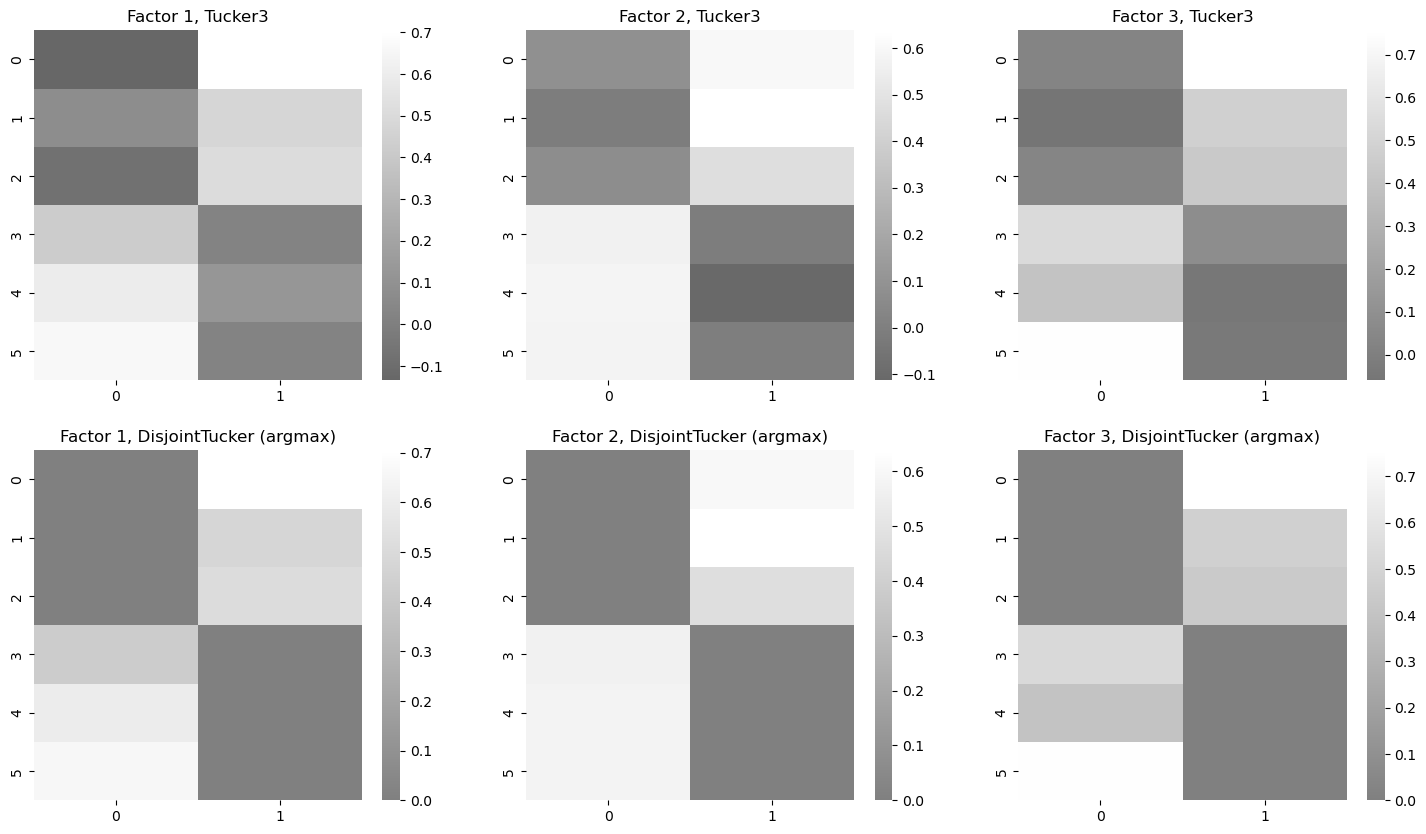

In [34]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
sns.heatmap(factors_std[0], cmap='grey', ax=axs[0, 0], center=0)
sns.heatmap(factors_std[1], cmap='grey', ax=axs[0, 1], center=0)
sns.heatmap(factors_std[2], cmap='grey', ax=axs[0, 2], center=0)
sns.heatmap(factors_dj[0], cmap='grey', ax=axs[1, 0], center=0)
sns.heatmap(factors_dj[1], cmap='grey', ax=axs[1, 1], center=0)
sns.heatmap(factors_dj[2], cmap='grey', ax=axs[1, 2], center=0)

axs[0, 0].set_title("Factor 1, Tucker3")
axs[0, 1].set_title("Factor 2, Tucker3")
axs[0, 2].set_title("Factor 3, Tucker3")

axs[1, 0].set_title("Factor 1, DisjointTucker (argmax)")
axs[1, 1].set_title("Factor 2, DisjointTucker (argmax)")
axs[1, 2].set_title("Factor 3, DisjointTucker (argmax)")

Попробуем нормировать факторы:

In [35]:
class DisjointTucker:
    def __init__(self, ranks=None, n_iter_max = 100, tol=1e-4, random_state=None):
        self.ranks = ranks
        self.n_iter_max = n_iter_max
        self.tol = tol
        self.random_state = random_state
        
        self.core = None
        self.factors = None

    def make_disjoint(self, M: tl.tensor):
        M_new = np.zeros_like(M)
        idx = np.argmax(np.abs(M), axis=1)

        for i in range(M.shape[0]):
            M_new[i, idx[i]] = M[i, idx[i]]
            
        norms = np.linalg.norm(M_new, axis=0, keepdims=True) + 1e-12
        M_new /= norms

        return M_new

    def compute_core(self, X: tl.tensor):
        self.core = tl.tenalg.multi_mode_dot(X, self.factors, transpose=True)
        return self

    def fit(self, X: tl.tensor):
        _, self.factors = tl.decomposition.tucker(X, rank=self.ranks)
        for iter in range(self.n_iter_max):
            for n in range(len(self.factors)):
                Y = X
                for i in range(len(self.factors)): 
                    if i != n:
                        Y = tl.tenalg.mode_dot(Y, self.factors[i].T, i)
                self.factors[n], _, _ = np.linalg.svd(tl.unfold(Y, n), full_matrices=False)
                if self.ranks != None:
                    self.factors[n] = self.factors[n][:, :self.ranks[n]]
                self.factors[n] = self.make_disjoint(self.factors[n])
        self.compute_core(X)
        return self

    def fit_transform(self, X: tl.tensor):
        self.fit(X)
        return self.core, self.factors

In [36]:
np.random.seed(42)
A = np.random.randn(6, 6, 6)
A[:3, :3, :3] += 2
A[3:, 3:, 3:] += 2

ranks = [2, 2, 2]
core, factors = tl.decomposition.tucker(A, rank=ranks)
A_approx = np.einsum('abc,ia,jb,kc->ijk', core, *factors)
print(f"Fit of Tucker3: {100-tl.norm(A-A_approx)/tl.norm(A) * 100}%")

disjoint_tucker = DisjointTucker(ranks=ranks)
core, factors = disjoint_tucker.fit_transform(A)
A_approx = np.einsum('abc,ia,jb,kc->ijk', core, *factors)
print(f"Fit of DisjointTucker, v1: {100-tl.norm(A-A_approx)/tl.norm(A) * 100}%")

Fit of Tucker3: 39.9098649842818%
Fit of DisjointTucker, v1: 38.40531872781299%


Попробуем тот же подход с Lasso Regression. Будем решать следующую задачу:
$$
    L(X, (G, Factors)) = ||X - [[G; Factors]]||^2_F + \alpha \sum_{F \in Factors} ||F||_{11} -> \min_{G, Factors}
$$
где 
$$
    ||F||_{11} = \sum_{i j} |f_{ij}|
$$
То есть сумма модулей всех элементов матрицы. Обычно решение данной задачи &mdash; разреженная матрица. Попробуем:

In [37]:
from sklearn.linear_model import Lasso

class DisjointTuckerLasso:
    def __init__(self, ranks=None, n_iter_max=100, tol=1e-4, random_state=None, alpha=0.01):
        self.ranks = ranks
        self.n_iter_max = n_iter_max
        self.tol = tol
        self.random_state = random_state
        self.alpha = alpha

        self.core = None
        self.U = None
        self.V = None
        self.W = None

    def compute_core(self, X: tl.tensor):
        self.core = tl.tenalg.multi_mode_dot(X, [self.U, self.V, self.W], transpose=True)
        return self

    def _enforce_disjoint(self, factor: tl.tensor):
        idx = tl.argmax(tl.abs(factor), axis=1)
        new_factor = tl.zeros_like(factor)
        rows = tl.arange(factor.shape[0])
        new_factor[rows, idx] = factor[rows, idx]
        return new_factor


    def fit(self, X: tl.tensor):
        X = tl.tensor(X)
        if self.random_state is not None:
            np.random.seed(self.random_state)
        if self.ranks is None:
            self.ranks = X.shape
            
        self.core, [self.U, self.V, self.W] = tl.decomposition.tucker(
           X, rank=self.ranks, init='svd', random_state=self.random_state
        )


        for _ in range(self.n_iter_max):
            X_mat = tl.kron(self.W, self.V) @ tl.unfold(self.core, 0).T
            Y_mat = tl.unfold(X, 0).T
            alpha = self.alpha * np.max(np.abs(X_mat.T @ Y_mat)) / X_mat.shape[0]
            model = Lasso(alpha=alpha, fit_intercept=False, max_iter=1000, random_state=self.random_state)
            model.fit(tl.to_numpy(X_mat), tl.to_numpy(Y_mat))
            self.U = model.coef_

            X_mat = tl.kron(self.W, self.U) @ tl.unfold(self.core, 1).T
            Y_mat = tl.unfold(X, 1).T
            alpha = self.alpha * np.max(np.abs(X_mat.T @ Y_mat)) / X_mat.shape[0]
            model = Lasso(alpha=alpha, fit_intercept=False, max_iter=1000, random_state=self.random_state)
            model.fit(tl.to_numpy(X_mat), tl.to_numpy(Y_mat))
            self.V = model.coef_

            X_mat = tl.kron(self.V, self.U) @ tl.unfold(self.core, 2).T
            Y_mat = tl.unfold(X, 2).T
            alpha = self.alpha * np.max(np.abs(X_mat.T @ Y_mat)) / X_mat.shape[0]
            model = Lasso(alpha=alpha, fit_intercept=False, max_iter=1000, random_state=self.random_state)
            model.fit(tl.to_numpy(X_mat), tl.to_numpy(Y_mat))
            self.W = model.coef_
            
            self.compute_core(X)
            
                
        return self

    def fit_transform(self, X: tl.tensor):
        self.fit(X)
        return self.core, [self.U, self.V, self.W]

In [48]:
np.random.seed(42)
A = np.random.randn(6, 6, 6)
A[:3, :3, :3] += 2
A[3:, 3:, 3:] += 2

ranks = [2, 2, 2]
random_state = 42
alpha=0.1

core_std, factors_std = tl.decomposition.tucker(A, rank=ranks, random_state=random_state)
fit_std = 100 * (1 - tl.norm(A - tl.tucker_to_tensor((core_std, factors_std))) / tl.norm(A))
print(f"Standard Tucker fit: {fit_std:.2f}%")

model = DisjointTuckerLasso(ranks=ranks, random_state=random_state, alpha=alpha)
core_dj, factors_dj = model.fit_transform(A)
fit_dj = 100 * (1 - tl.norm(A - tl.tucker_to_tensor((core_dj, factors_dj))) / tl.norm(A))
print(f"Disjoint Lasso Tucker fit: {fit_dj:.2f}%")

Standard Tucker fit: 39.91%
Disjoint Lasso Tucker fit: 24.28%


Text(0.5, 1.0, 'Factor 3, DisjointTucker (Lasso)')

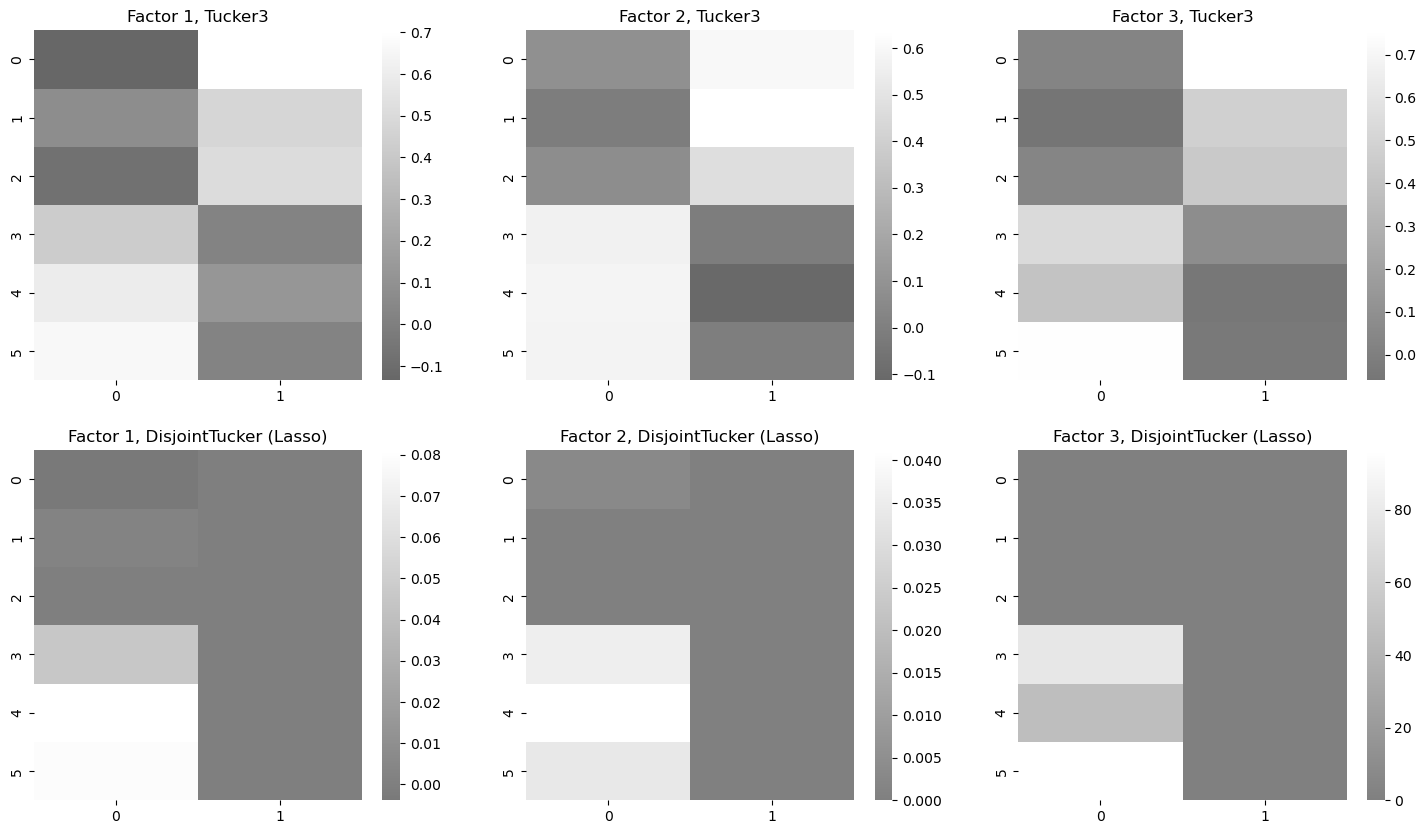

In [49]:
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
sns.heatmap(factors_std[0], cmap='grey', ax=axs[0, 0], center=0)
sns.heatmap(factors_std[1], cmap='grey', ax=axs[0, 1], center=0)
sns.heatmap(factors_std[2], cmap='grey', ax=axs[0, 2], center=0)
sns.heatmap(factors_dj[0], cmap='grey', ax=axs[1, 0], center=0)
sns.heatmap(factors_dj[1], cmap='grey', ax=axs[1, 1], center=0)
sns.heatmap(factors_dj[2], cmap='grey', ax=axs[1, 2], center=0)

axs[0, 0].set_title("Factor 1, Tucker3")
axs[0, 1].set_title("Factor 2, Tucker3")
axs[0, 2].set_title("Factor 3, Tucker3")

axs[1, 0].set_title("Factor 1, DisjointTucker (Lasso)")
axs[1, 1].set_title("Factor 2, DisjointTucker (Lasso)")
axs[1, 2].set_title("Factor 3, DisjointTucker (Lasso)")

Разложение "потеряло" один из кластеров.

In [52]:
import numpy as np
import tensorly as tl
from scipy.linalg import svd

class DisjointTucker:
    """
    Disjoint Tucker decomposition via ALS with Vichi & Saporta disjoint PCA.
    Reference: Cascante-Varleque et. al. (2025)
    """
    
    def __init__(self, ranks=None, n_iter_max=100, tol=1e-4, 
                 random_state=None, disjoint_modes=None):
        """
        Parameters
        ----------
        ranks : list[int] or None
            Number of components per mode. If None, uses full rank.
        n_iter_max : int
            Maximum ALS iterations.
        tol : float
            Convergence tolerance on relative fit change.
        random_state : int or None
            Seed for reproducibility.
        disjoint_modes : list[int] or None
            Which modes should have disjoint factors (0-indexed).
            If None, all disjoint constraints are applied.
        """
        self.ranks = ranks
        self.n_iter_max = n_iter_max
        self.tol = tol
        self.random_state = random_state
        self.disjoint_modes = disjoint_modes
        
        self.core = None
        self.factors = None
        self.fit_history_ = []

    def _disjoint_pca(self, X: np.ndarray, n_components: int, n_iter_max=100, tol=1e-6):
        """
        Vichi & Saporta algorithm for disjoint orthogonal PCA.
        Input: X (n_samples, n_features), Output: disjoint orthogonal B (n_features, n_components).
        Reference: Vichi & Saporta (2009)
        """
        n, p = X.shape
        np.random.seed(self.random_state)

        # 1. Initializaton: Random orthogonal matrix
        B = np.random.randn(p, n_components)
        B, _ = np.linalg.qr(B)
        
        for iter in range(n_iter_max):
            B_old = B.copy()
            
            # 2. Assignment: assign each row of X with column of maximum correlation
            scores = np.abs(X @ B)
            assignments = np.argmax(scores, axis=1)
            
            # 3. Update: update B on assignments
            B_new = np.zeros((p, n_components))
            for r in range(n_components):
                mask = (assignments == r)
                if np.any(mask):
                    B_new[:, r] = X[mask].mean(axis=0)
                else:
                    B_new[:, r] = B[:, r]  
                    
            # 4. Orhogonalization
            Q, _ = np.linalg.qr(B_new)
            
            # 5. Disjoint projection: leave maximum element in each row
            for i in range(p):
                row = Q[i, :].copy()
                idx = np.argmax(np.abs(row))
                Q[i, :] = 0.0
                Q[i, idx] = row[idx]
                
            # 6. Normalize columns
            Q /= np.linalg.norm(Q, axis=0) + 1e-12
                
            B = Q
            if np.linalg.norm(B - B_old) / (np.linalg.norm(B_old) + 1e-12) < tol:
                break
                
        return B

    def _update_factor_disjoint(self, X, n):
        """Update factor n with disjoint constraint using DisjointPCA."""
        R_n = self.ranks[n]
        
        X_unf = tl.unfold(X, n)
        X_pca = tl.to_numpy(X_unf.T)
        
        B_disjoint = self._disjoint_pca(X_pca, n_components=R_n, tol=self.tol, n_iter_max=self.n_iter_max)  
        
        return tl.tensor(B_disjoint)

    def _update_factor_standard(self, X, n):
        """Standard ALS update for factor n (no constraints)."""
        R_n = self.ranks[n]       
        Y = X
        for m in range(X.ndim):
            if m != n:
                Y = tl.tenalg.mode_dot(Y, self.factors[m].T, m)
        
        Y_unf = tl.unfold(Y, n)
        A_n, _, _ = tl.svd(Y_unf)
        
        return A_n[:, :R_n]

    def compute_core(self, X):
        """Compute core tensor for given factors and X: G = X ×_1 A1^T ×_2 ... ×_N AN^T"""
        self.core = tl.tenalg.multi_mode_dot(X, self.factors, transpose=True)
        return self

    def _compute_fit(self, X):
        """Compute reconstruction fit: 100 * (1 - ||X-X_rec||/||X||)"""
        X_rec = tl.tucker_to_tensor((self.core, self.factors))
        return 100 * (1 - tl.norm(X - X_rec) / (tl.norm(X) + 1e-12))

    def fit(self, X):
        X = tl.tensor(X)
        if self.random_state is not None:
            np.random.seed(self.random_state)
        if self.disjoint_modes is None:
            self.disjoint_modes = list(range(X.ndim))
        
        if self.ranks is None:
            self.ranks = list(X.shape)
        else:
            self.ranks = list(self.ranks)
        
        # initialize with HOOI
        self.core, self.factors = tl.decomposition.tucker(
            X, rank=self.ranks, init='svd', random_state=self.random_state
        ) 

        prev_fit = -np.inf
        for iter in range(self.n_iter_max):
            for n in range(X.ndim):
                if n in self.disjoint_modes:
                    self.factors[n] = self._update_factor_disjoint(X, n)
                else:
                    self.factors[n] = self._update_factor_standard(X, n)
            
            self.compute_core(X)
            
            current_fit = self._compute_fit(X)
            self.fit_history_.append(current_fit)
            
            if abs(current_fit - prev_fit) / (abs(prev_fit) + 1e-12) < self.tol:
                break
            prev_fit = current_fit
            
        return self

    def fit_transform(self, X):
        self.fit(X)
        return self.core, self.factors

# Код сгенерирован нейросетью Qwen

In [53]:
np.random.seed(42)
A = np.random.randn(6, 6, 6)
A[:3, :3, :3] += 2
A[3:, 3:, 3:] += 2

ranks = [2, 2, 2]
random_state = 42

core_std, factors_std = tl.decomposition.tucker(A, rank=ranks, random_state=random_state)
fit_std = 100 * (1 - tl.norm(A - tl.tucker_to_tensor((core_std, factors_std))) / tl.norm(A))
print(f"Standard Tucker fit: {fit_std:.2f}%")

model = DisjointTucker(ranks=ranks, random_state=random_state)
core_dj, factors_dj = model.fit_transform(A)
fit_dj = 100 * (1 - tl.norm(A - tl.tucker_to_tensor((core_dj, factors_dj))) / tl.norm(A))
print(f"Disjoint Tucker fit: {fit_dj:.2f}%")

Standard Tucker fit: 39.91%
Disjoint Tucker fit: 35.92%


C:\Users\vorkm\AppData\Local\Temp\ipykernel_32156\3666093441.py:150: RuntimeWarning: invalid value encountered in scalar divide
  if abs(current_fit - prev_fit) / (abs(prev_fit) + 1e-12) < self.tol:


Text(0.5, 1.0, 'Factor 3, DisjointTucker')

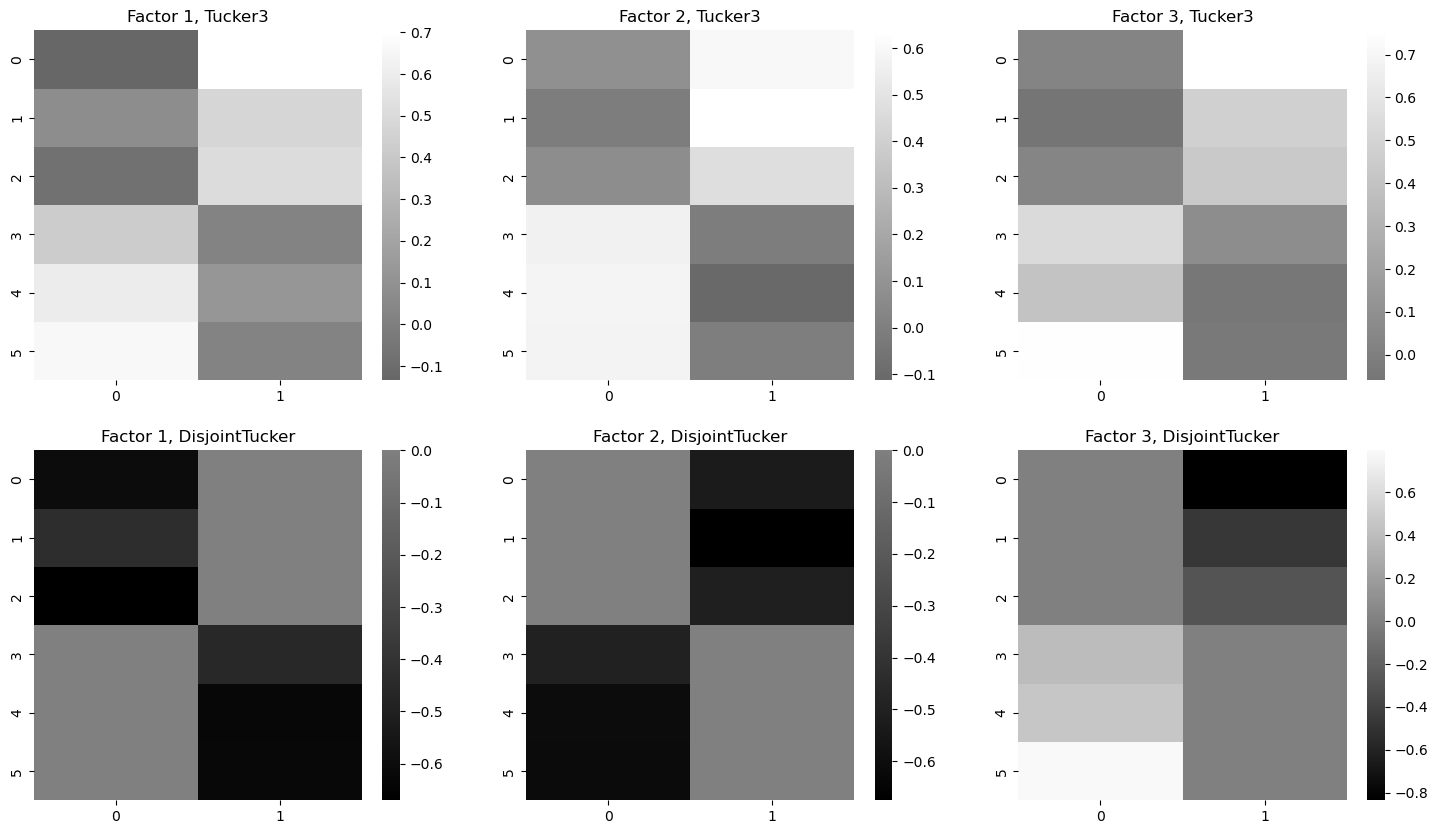

In [54]:
import seaborn as sns

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
sns.heatmap(factors_std[0], cmap='grey', ax=axs[0, 0], center=0)
sns.heatmap(factors_std[1], cmap='grey', ax=axs[0, 1], center=0)
sns.heatmap(factors_std[2], cmap='grey', ax=axs[0, 2], center=0)
sns.heatmap(factors_dj[0], cmap='grey', ax=axs[1, 0], center=0)
sns.heatmap(factors_dj[1], cmap='grey', ax=axs[1, 1], center=0)
sns.heatmap(factors_dj[2], cmap='grey', ax=axs[1, 2], center=0)

axs[0, 0].set_title("Factor 1, Tucker3")
axs[0, 1].set_title("Factor 2, Tucker3")
axs[0, 2].set_title("Factor 3, Tucker3")

axs[1, 0].set_title("Factor 1, DisjointTucker")
axs[1, 1].set_title("Factor 2, DisjointTucker")
axs[1, 2].set_title("Factor 3, DisjointTucker")

По полученным disjoint factors можно отследить, какому кластеру принадлежит каждая строчка в соответствующей моде.